<a href="https://colab.research.google.com/github/Emma-Ok/MonitoriasLogica2/blob/2025-1/PhishingDetectedGraphicsSeaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración inicial
plt.style.use('default')
sns.set_theme( style="white",
              palette="pastel",
              context="paper",)
plt.rcParams['figure.figsize'] = (12, 8)

url = "https://raw.githubusercontent.com/Emma-Ok/Phishing-Detection-ML/main/Phishing_Legitimate_full.csv"
df = pd.read_csv(url)
df = df.drop(columns=['id'])
print("Dataset creado con éxito!")
print(f"Dimensiones: {df.shape}")


print(f"\nDistribución de phishing:")
print(df['CLASS_LABEL'].value_counts())


Dataset creado con éxito!
Dimensiones: (10000, 49)

Distribución de phishing:
CLASS_LABEL
1    5000
0    5000
Name: count, dtype: int64


| No. | Feature                                      | Type          | Description                                                                                       |
|-----|----------------------------------------------|---------------|---------------------------------------------------------------------------------------------------|
| 1   | NumDots                                      | Discrete      | Counts the number of dots in webpage URL                                                           |
| 2   | SubdomainLevel                               | Discrete      | Counts the level of subdomain in webpage URL                                                      |
| 3   | PathLevel                                    | Discrete      | Counts the depth of the path in webpage URL                                                       |
| 4   | UrlLength                                    | Discrete      | Counts the total characters in the webpage URL                                                    |
| 5   | NumDash                                      | Discrete      | Counts the number of “-” in webpage URL                                                           |
| 6   | NumDashInHostname                            | Discrete      | Counts the number of “-” in hostname part of webpage URL                                          |
| 7   | AtSymbol                                     | Binary        | Checks if “@” symbol exist in webpage URL                                                         |
| 8   | TildeSymbol                                  | Binary        | Checks if “∼” symbol exist in webpage URL                                                         |
| 9   | NumUnderscore                                | Discrete      | Counts the number of “_” in webpage URL                                                           |
| 10  | NumPercent                                   | Discrete      | Counts the number of “%” in webpage URL                                                           |
| 11  | NumQueryComponents                           | Discrete      | Counts the number of query parts in webpage URL                                                   |
| 12  | NumAmpersand                                 | Discrete      | Counts the number of “&” in webpage URL                                                           |
| 13  | NumHash                                      | Discrete      | Counts the number of “#” in webpage URL                                                           |
| 14  | NumNumericChars                              | Discrete      | Counts the number of numeric characters in the webpage URL                                        |
| 15  | NoHttps                                      | Binary        | Checks if HTTPS exist in webpage URL                                                              |
| 16  | RandomString                                 | Binary        | Checks if random strings exist in webpage URL                                                     |
| 17  | IpAddress                                    | Binary        | Checks if IP address is used in hostname part of webpage URL                                      |
| 18  | DomainInSubdomains                           | Binary        | Checks if TLD or ccTLD is used as part of subdomain in webpage URL                               |
| 19  | DomainInPaths                                | Binary        | Checks if TLD or ccTLD is used in the path of webpage URL                                        |
| 20  | HttpsInHostname                              | Binary        | Checks if HTTPS is obfuscated in hostname part of webpage URL                                    |
| 21  | HostnameLength                               | Discrete      | Counts the total characters in hostname part of webpage URL                                       |
| 22  | PathLength                                   | Discrete      | Counts the total characters in path of webpage URL                                               |
| 23  | QueryLength                                  | Discrete      | Counts the total characters in query part of webpage URL                                         |
| 24  | DoubleSlashInPath                            | Binary        | Checks if “//” exist in the path of webpage URL                                                   |
| 25  | NumSensitiveWords                            | Discrete      | Counts the number of sensitive words (e.g., “secure,” “account,” “login,” etc.) in webpage URL   |
| 26  | EmbeddedBrandName                            | Binary        | Checks if brand name appears in subdomains and path; brand = most frequent domain in HTML        |
| 27  | PctExtHyperlinks                             | Continuous    | Percentage of external hyperlinks in HTML source code                                            |
| 28  | PctExtResourceUrls                           | Continuous    | Percentage of external resource URLs in HTML source code                                         |
| 29  | ExtFavicon                                   | Binary        | Checks if favicon is loaded from a different domain                                              |
| 30  | InsecureForms                                | Binary        | Checks if form action URL lacks HTTPS protocol                                                    |
| 31  | RelativeFormAction                           | Binary        | Checks if form action URL is relative                                                            |
| 32  | ExtFormAction                                | Binary        | Checks if form action URL is external domain                                                     |
| 33  | AbnormalFormAction                           | Categorical   | Form action contains “#,” “about:blank,” empty, or “javascript:true”                                     |
| 34  | PctNullSelfRedirectHyperlinks                | Continuous    | Pct. of hyperlinks empty, self-redirect (“#”), current URL, or abnormal                                             |
| 35  | FrequentDomainNameMismatch                   | Binary        | Most frequent domain in HTML ≠ webpage URL domain                                                |
| 36  | FakeLinkInStatusBar                          | Binary        | Checks if onMouseOver JS shows fake URL in status bar                                            |
| 37  | RightClickDisabled                           | Binary        | Checks if JS disables right-click function                                                       |
| 38  | PopUpWindow                                  | Binary        | Checks if JS launches pop-up windows                                                             |
| 39  | SubmitInfoToEmail                            | Binary        | Checks if HTML uses “mailto” in forms                                                            |
| 40  | IframeOrFrame                                | Binary        | Checks if iframe or frame tags are used                                                          |
| 41  | MissingTitle                                 | Binary        | Checks if the title tag is empty                                                               |
| 42  | ImagesOnlyInForm                             | Binary        | Form scope contains only images, no text                                                         |
| 43  | SubdomainLevelRT                             | Categorical   | Counts dots in hostname (reinforced thresholds)                                                  |
| 44  | UrlLengthRT                                  | Categorical   | URL length with applied rules/thresholds                                                         |
| 45  | PctExtResourceUrlsRT                         | Categorical   | Pct. of external resource URLs (categorical)                                                     |
| 46  | AbnormalExtFormActionR                       | Categorical   | Form action foreign domain, “about:blank”, or empty                                              |
| 47  | ExtMetaScriptLinkRT                          | Categorical   | Pct. of meta, script, link tags with external URLs                                               |
| 48  | PctExtNullSelfRedirect-HyperlinksRT          | Categorical   | Pct. of hyperlinks external, “#,” or “JavaScript:: void(0)”                                      |

In [5]:
# Análisis Completo de Phishing - Dataset Real + LASSO + Seaborn Pastel
# ========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

print("🎨 ANÁLISIS PROFESIONAL DE PHISHING - DATASET REAL")
print("🔍 48 Características")
print("=" * 70)

# Usar el DataFrame ya cargado
phishing_data = df.copy()

print("📋 INFORMACIÓN DEL DATASET REAL:")
print(f"✅ Dimensiones: {phishing_data.shape}")
print(f"🎯 Distribución CLASS_LABEL:")
print(f"   - No Phishing (0): {(phishing_data['CLASS_LABEL']==0).sum():,} ({(phishing_data['CLASS_LABEL']==0).mean()*100:.1f}%)")
print(f"   - Phishing (1): {(phishing_data['CLASS_LABEL']==1).sum():,} ({(phishing_data['CLASS_LABEL']==1).mean()*100:.1f}%)")

print(f"\n📊 Características disponibles: {phishing_data.shape[1] - 1}")
print("Tipos de datos:")
print(phishing_data.dtypes.value_counts())

# Lista de características del dataset real (excluyendo CLASS_LABEL)
feature_columns = [col for col in phishing_data.columns if col != 'CLASS_LABEL']
print(f"\n📋 CARACTERÍSTICAS DEL DATASET ({len(feature_columns)}):")
for i, col in enumerate(feature_columns, 1):
    if i % 4 == 1:
        print()
    print(f"{i:2d}. {col:25}", end=" ")
print("\n")









🎨 ANÁLISIS PROFESIONAL DE PHISHING - DATASET REAL
🔍 48 Características
📋 INFORMACIÓN DEL DATASET REAL:
✅ Dimensiones: (10000, 49)
🎯 Distribución CLASS_LABEL:
   - No Phishing (0): 5,000 (50.0%)
   - Phishing (1): 5,000 (50.0%)

📊 Características disponibles: 48
Tipos de datos:
int64      46
float64     3
Name: count, dtype: int64

📋 CARACTERÍSTICAS DEL DATASET (48):

 1. NumDots                    2. SubdomainLevel             3. PathLevel                  4. UrlLength                 
 5. NumDash                    6. NumDashInHostname          7. AtSymbol                   8. TildeSymbol               
 9. NumUnderscore             10. NumPercent                11. NumQueryComponents        12. NumAmpersand              
13. NumHash                   14. NumNumericChars           15. NoHttps                   16. RandomString              
17. IpAddress                 18. DomainInSubdomains        19. DomainInPaths             20. HttpsInHostname           
21. HostnameLength       



🎨 1. ANÁLISIS EXPLORATORIO - ESTILO PASTEL
📊 Características numéricas identificadas: 48
📊 Características binarias identificadas: 30


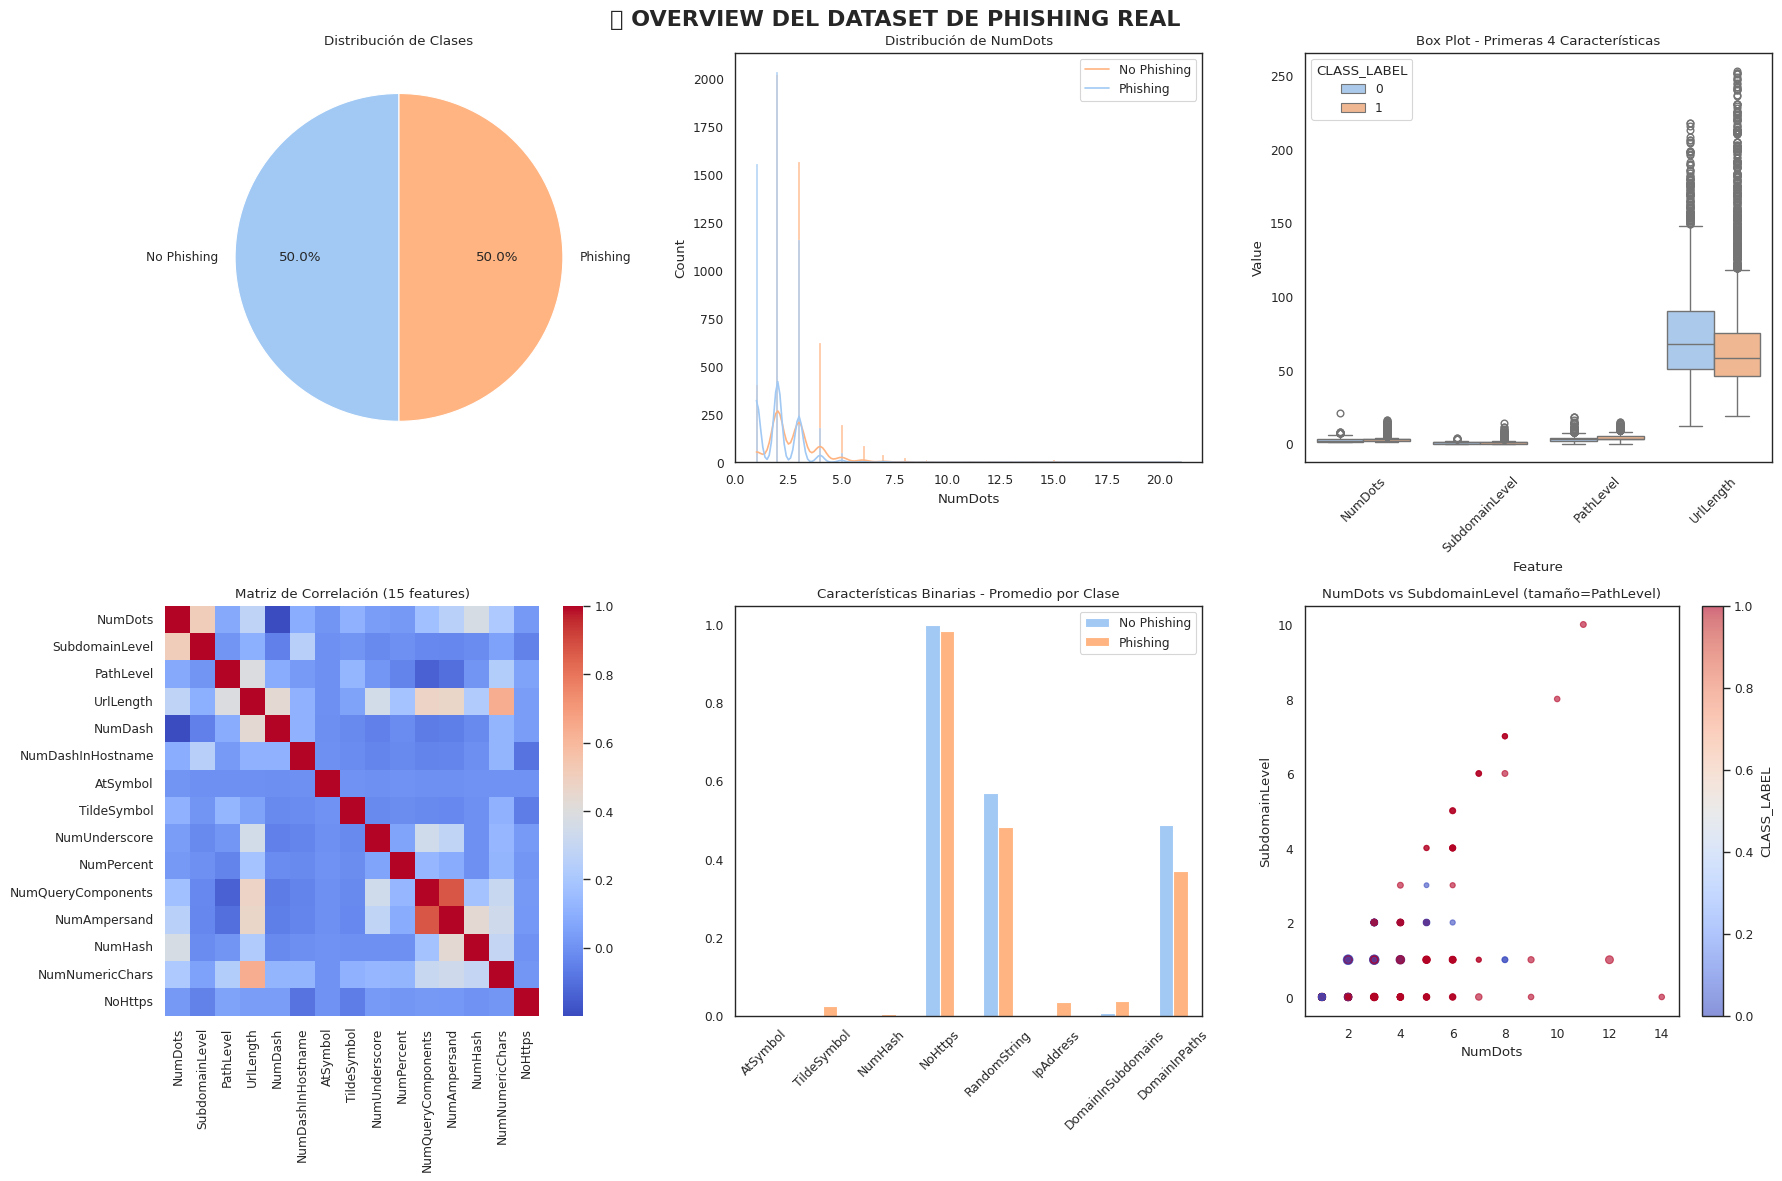

In [ ]:
# =============================================================================
# 1. ANÁLISIS EXPLORATORIO INICIAL CON ESTILO PASTEL
# =============================================================================

print("\n\n🎨 1. ANÁLISIS EXPLORATORIO - ESTILO PASTEL")
print("=" * 50)

# 1.1 Overview del dataset
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('🔍 OVERVIEW DEL DATASET DE PHISHING REAL', fontsize=16, fontweight='bold')

# Distribución de clases
axes[0, 0].pie(phishing_data['CLASS_LABEL'].value_counts().values,
               labels=['No Phishing', 'Phishing'], autopct='%1.1f%%',
               colors=sns.color_palette("pastel")[0:2], startangle=90)
axes[0, 0].set_title('Distribución de Clases')

# Identificar características numéricas
numeric_features = phishing_data.select_dtypes(include=[np.number]).columns.tolist()
if 'CLASS_LABEL' in numeric_features:
    numeric_features.remove('CLASS_LABEL')

print(f"📊 Características numéricas identificadas: {len(numeric_features)}")

# Distribución de una característica principal (primera numérica disponible)
main_feature = numeric_features[0] if numeric_features else 'UrlLength'
if main_feature in phishing_data.columns:
    sns.histplot(data=phishing_data, x=main_feature, hue='CLASS_LABEL',
                 kde=True, alpha=0.7, ax=axes[0, 1])
    axes[0, 1].set_title(f'Distribución de {main_feature}')
    axes[0, 1].legend(['No Phishing', 'Phishing'])

# Box plot de las primeras 4 características
key_features = numeric_features[:4] if len(numeric_features) >= 4 else numeric_features
if key_features:
    melted_data = pd.melt(phishing_data[key_features + ['CLASS_LABEL']],
                          id_vars=['CLASS_LABEL'], var_name='Feature', value_name='Value')
    sns.boxplot(data=melted_data, x='Feature', y='Value', hue='CLASS_LABEL', ax=axes[0, 2])
    axes[0, 2].set_title('Box Plot - Primeras 4 Características')
    axes[0, 2].tick_params(axis='x', rotation=45)

# Correlación inicial (primeras 15 características numéricas)
corr_features = numeric_features[:15] if len(numeric_features) >= 15 else numeric_features
if corr_features:
    correlation_matrix = phishing_data[corr_features].corr()
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', ax=axes[1, 0])
    axes[1, 0].set_title(f'Matriz de Correlación ({len(corr_features)} features)')

# Identificar características binarias (valores únicos <= 3)
binary_features = []
for col in feature_columns:
    unique_vals = phishing_data[col].nunique()
    if unique_vals <= 3:
        binary_features.append(col)

print(f"📊 Características binarias identificadas: {len(binary_features)}")

# Análisis de características binarias
if binary_features:
    binary_cols = binary_features[:8]  # Primeras 8
    binary_summary = phishing_data.groupby('CLASS_LABEL')[binary_cols].mean()
    binary_summary.T.plot(kind='bar', ax=axes[1, 1], color=sns.color_palette("pastel"))
    axes[1, 1].set_title('Características Binarias - Promedio por Clase')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].legend(['No Phishing', 'Phishing'])

# Scatter plot multidimensional
if len(numeric_features) >= 3:
    sample_data = phishing_data.sample(min(2000, len(phishing_data)))
    feat1, feat2, feat3 = numeric_features[0], numeric_features[1], numeric_features[2]

    scatter = axes[1, 2].scatter(sample_data[feat1], sample_data[feat2],
                                c=sample_data['CLASS_LABEL'],
                                s=sample_data[feat3]*2 + 10,
                                alpha=0.6, cmap='coolwarm')
    axes[1, 2].set_xlabel(feat1)
    axes[1, 2].set_ylabel(feat2)
    axes[1, 2].set_title(f'{feat1} vs {feat2} (tamaño={feat3})')
    plt.colorbar(scatter, ax=axes[1, 2], label='CLASS_LABEL')

plt.tight_layout()
plt.show()



📊 DASHBOARD VISUAL DE TODAS LAS CARACTERÍSTICAS


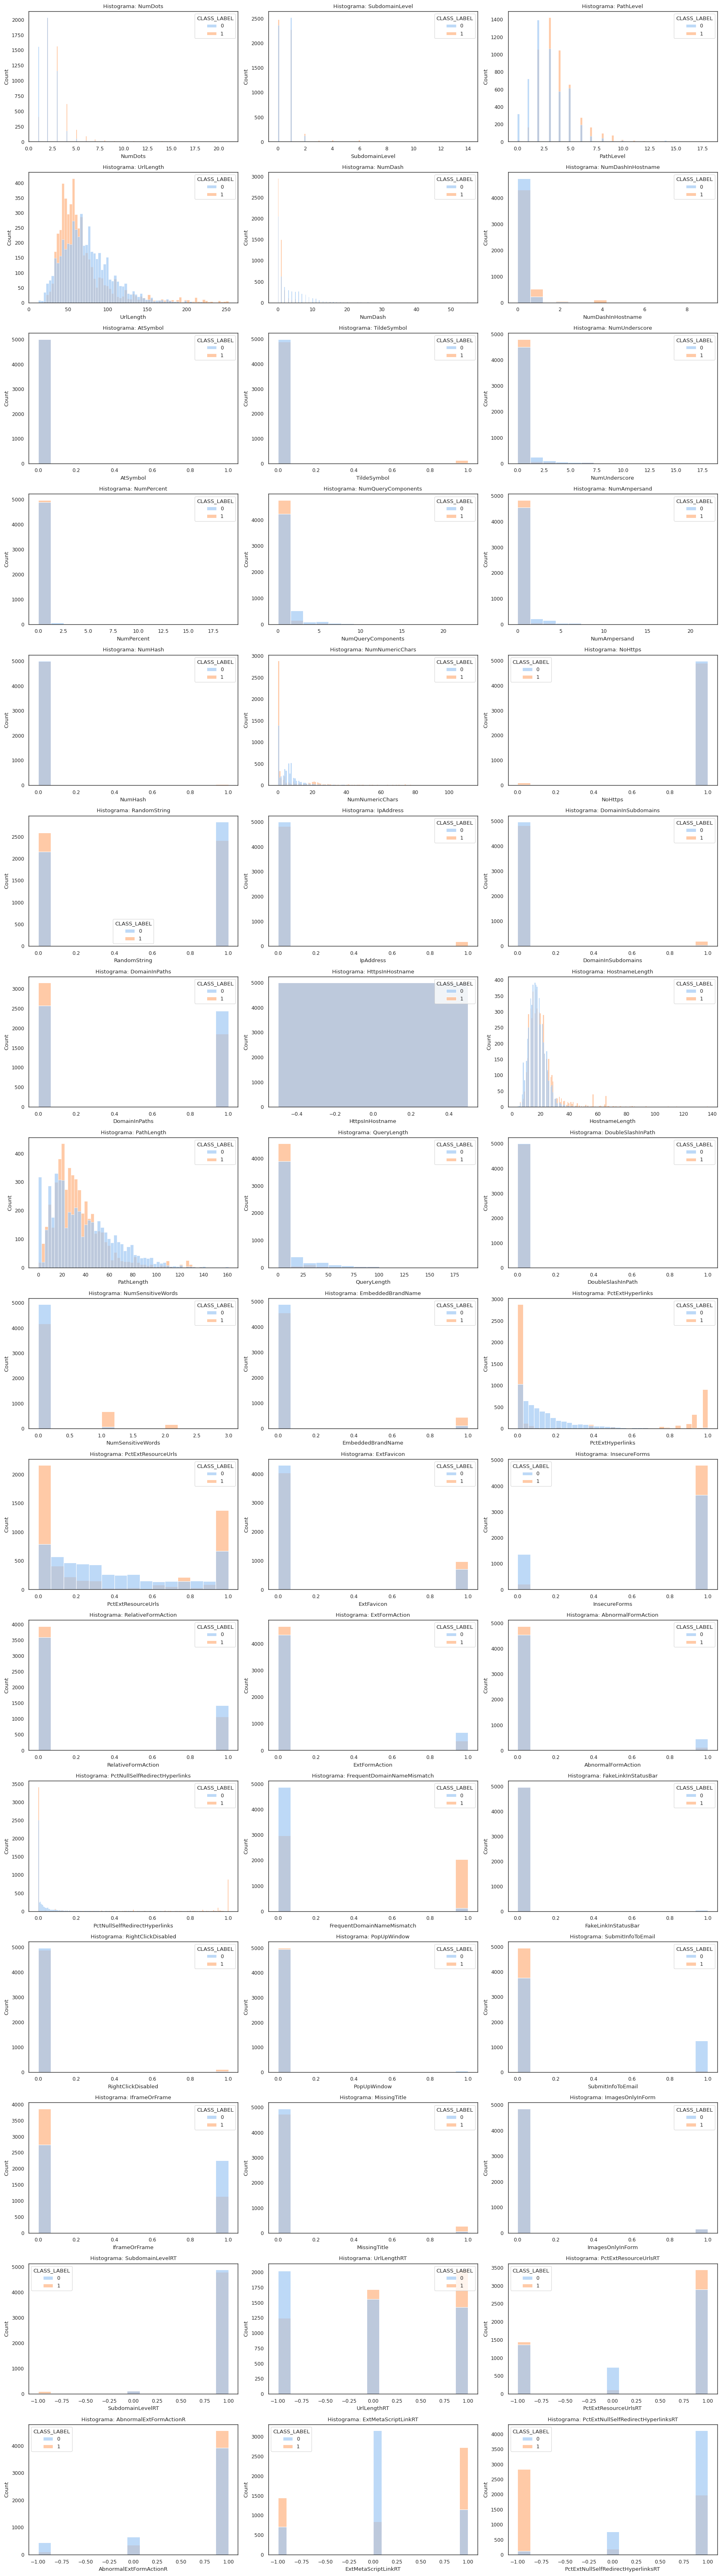

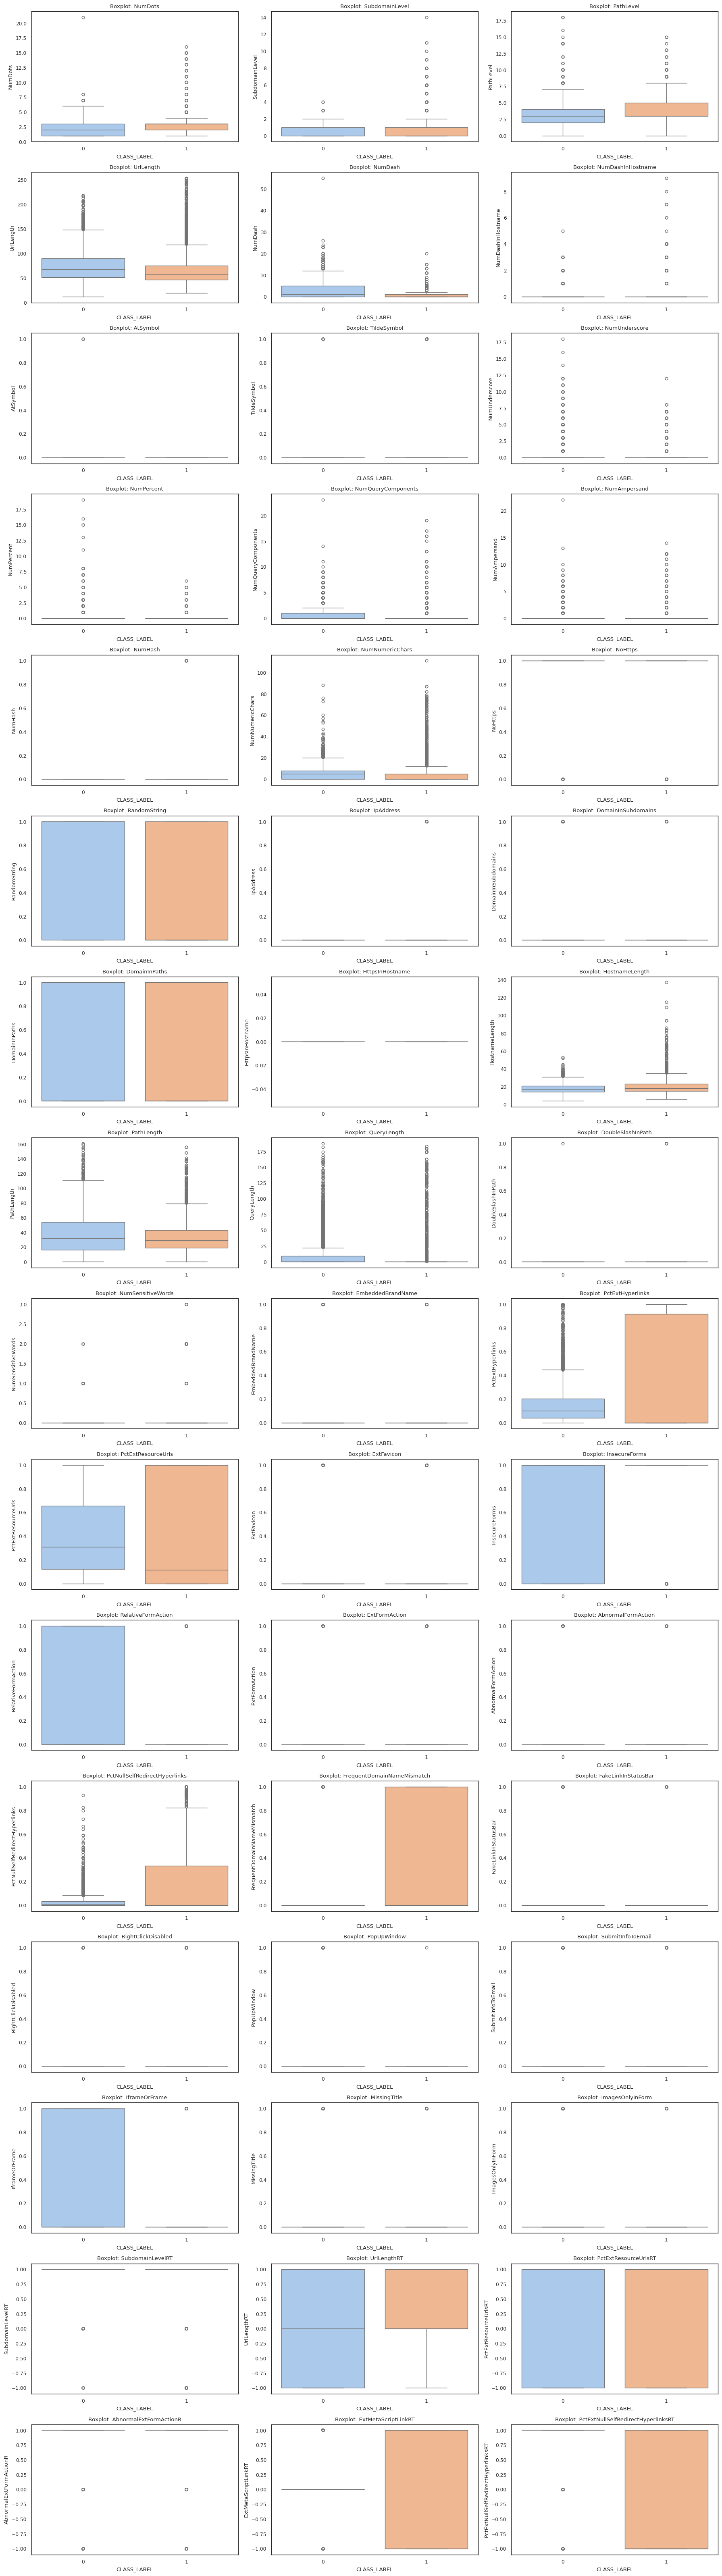

In [ ]:
#
# =============================================================================
# DASHBOARD VISUAL DE TODAS LAS CARACTERÍSTICAS CON SEABORN
# =============================================================================

print("\n\n📊 DASHBOARD VISUAL DE TODAS LAS CARACTERÍSTICAS")
print("=" * 55)

from math import ceil

# 1. Histogramas y boxplots para todas las numéricas
numeric_cols = phishing_data.select_dtypes(include=[np.number]).columns.tolist()
if 'CLASS_LABEL' in numeric_cols:
    numeric_cols.remove('CLASS_LABEL')

n_num = len(numeric_cols)
if n_num > 0:
    ncols = 3
    nrows = ceil(n_num / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        try:
            sns.histplot(data=phishing_data, x=col, hue='CLASS_LABEL', ax=axes[i], palette="pastel", alpha=0.7)
            axes[i].set_title(f'Histograma: {col}')
        except Exception as e:
            axes[i].set_visible(False)
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        try:
            sns.boxplot(data=phishing_data, x='CLASS_LABEL', y=col, ax=axes[i], palette="pastel")
            axes[i].set_title(f'Boxplot: {col}')
        except Exception as e:
            axes[i].set_visible(False)
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()




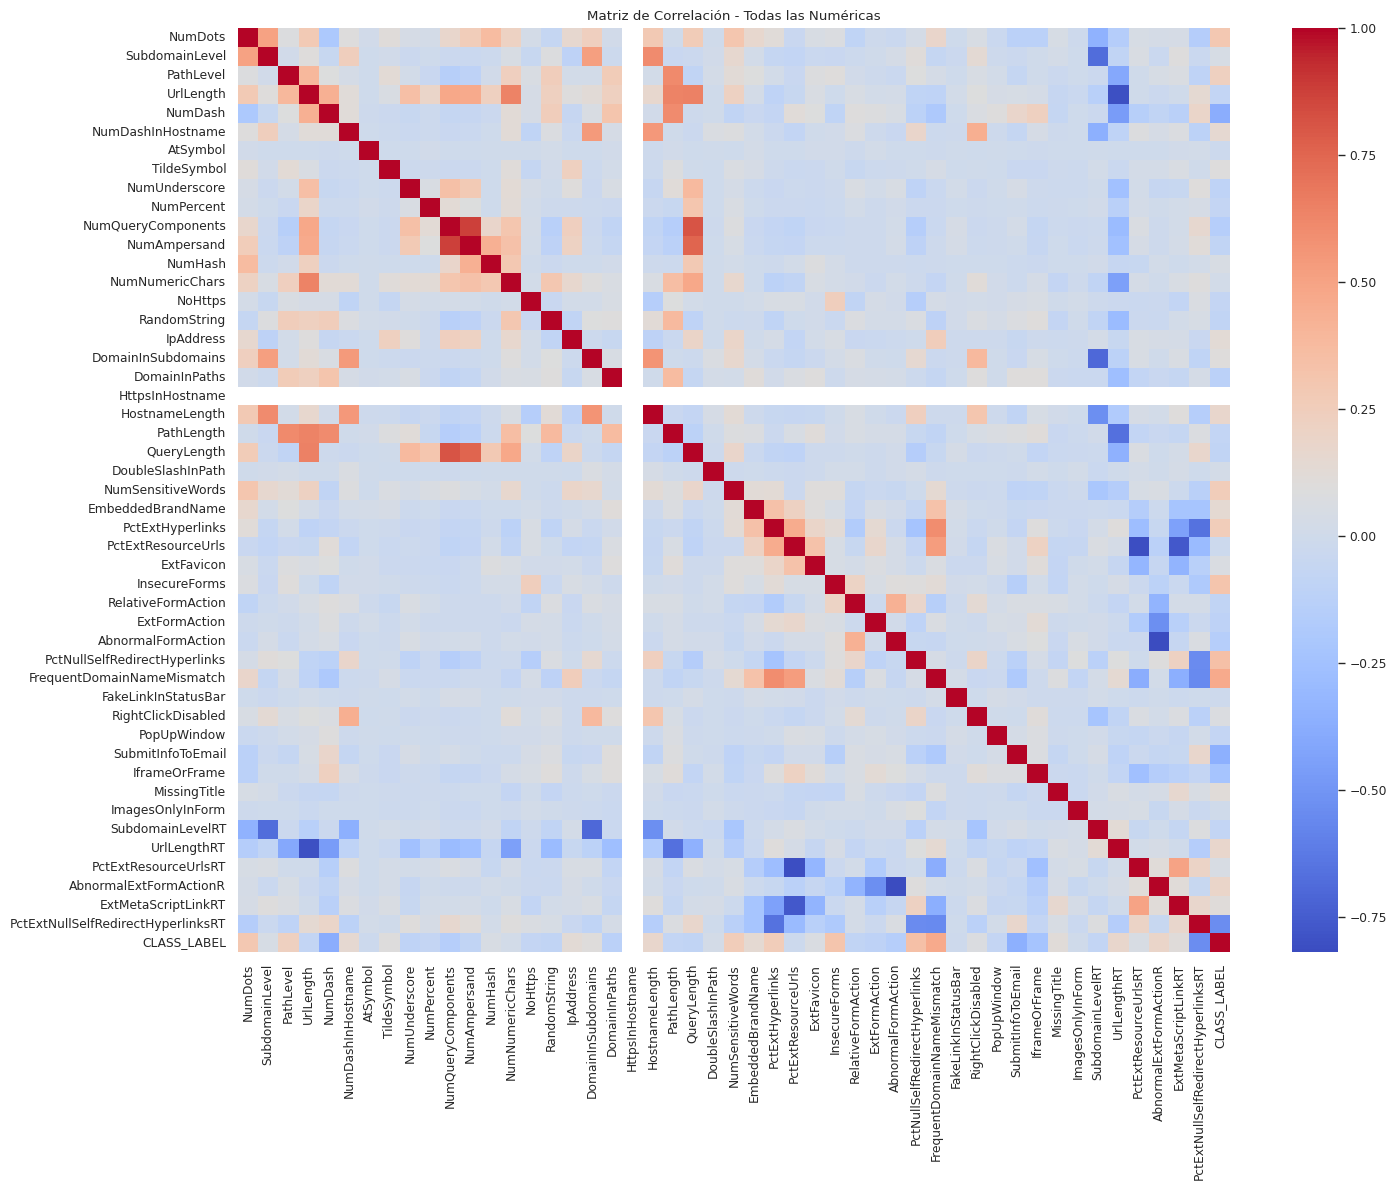

In [ ]:
plt.figure(figsize=(16, 12))
corr = phishing_data[numeric_cols + ['CLASS_LABEL']].corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Matriz de Correlación - Todas las Numéricas')
plt.show()

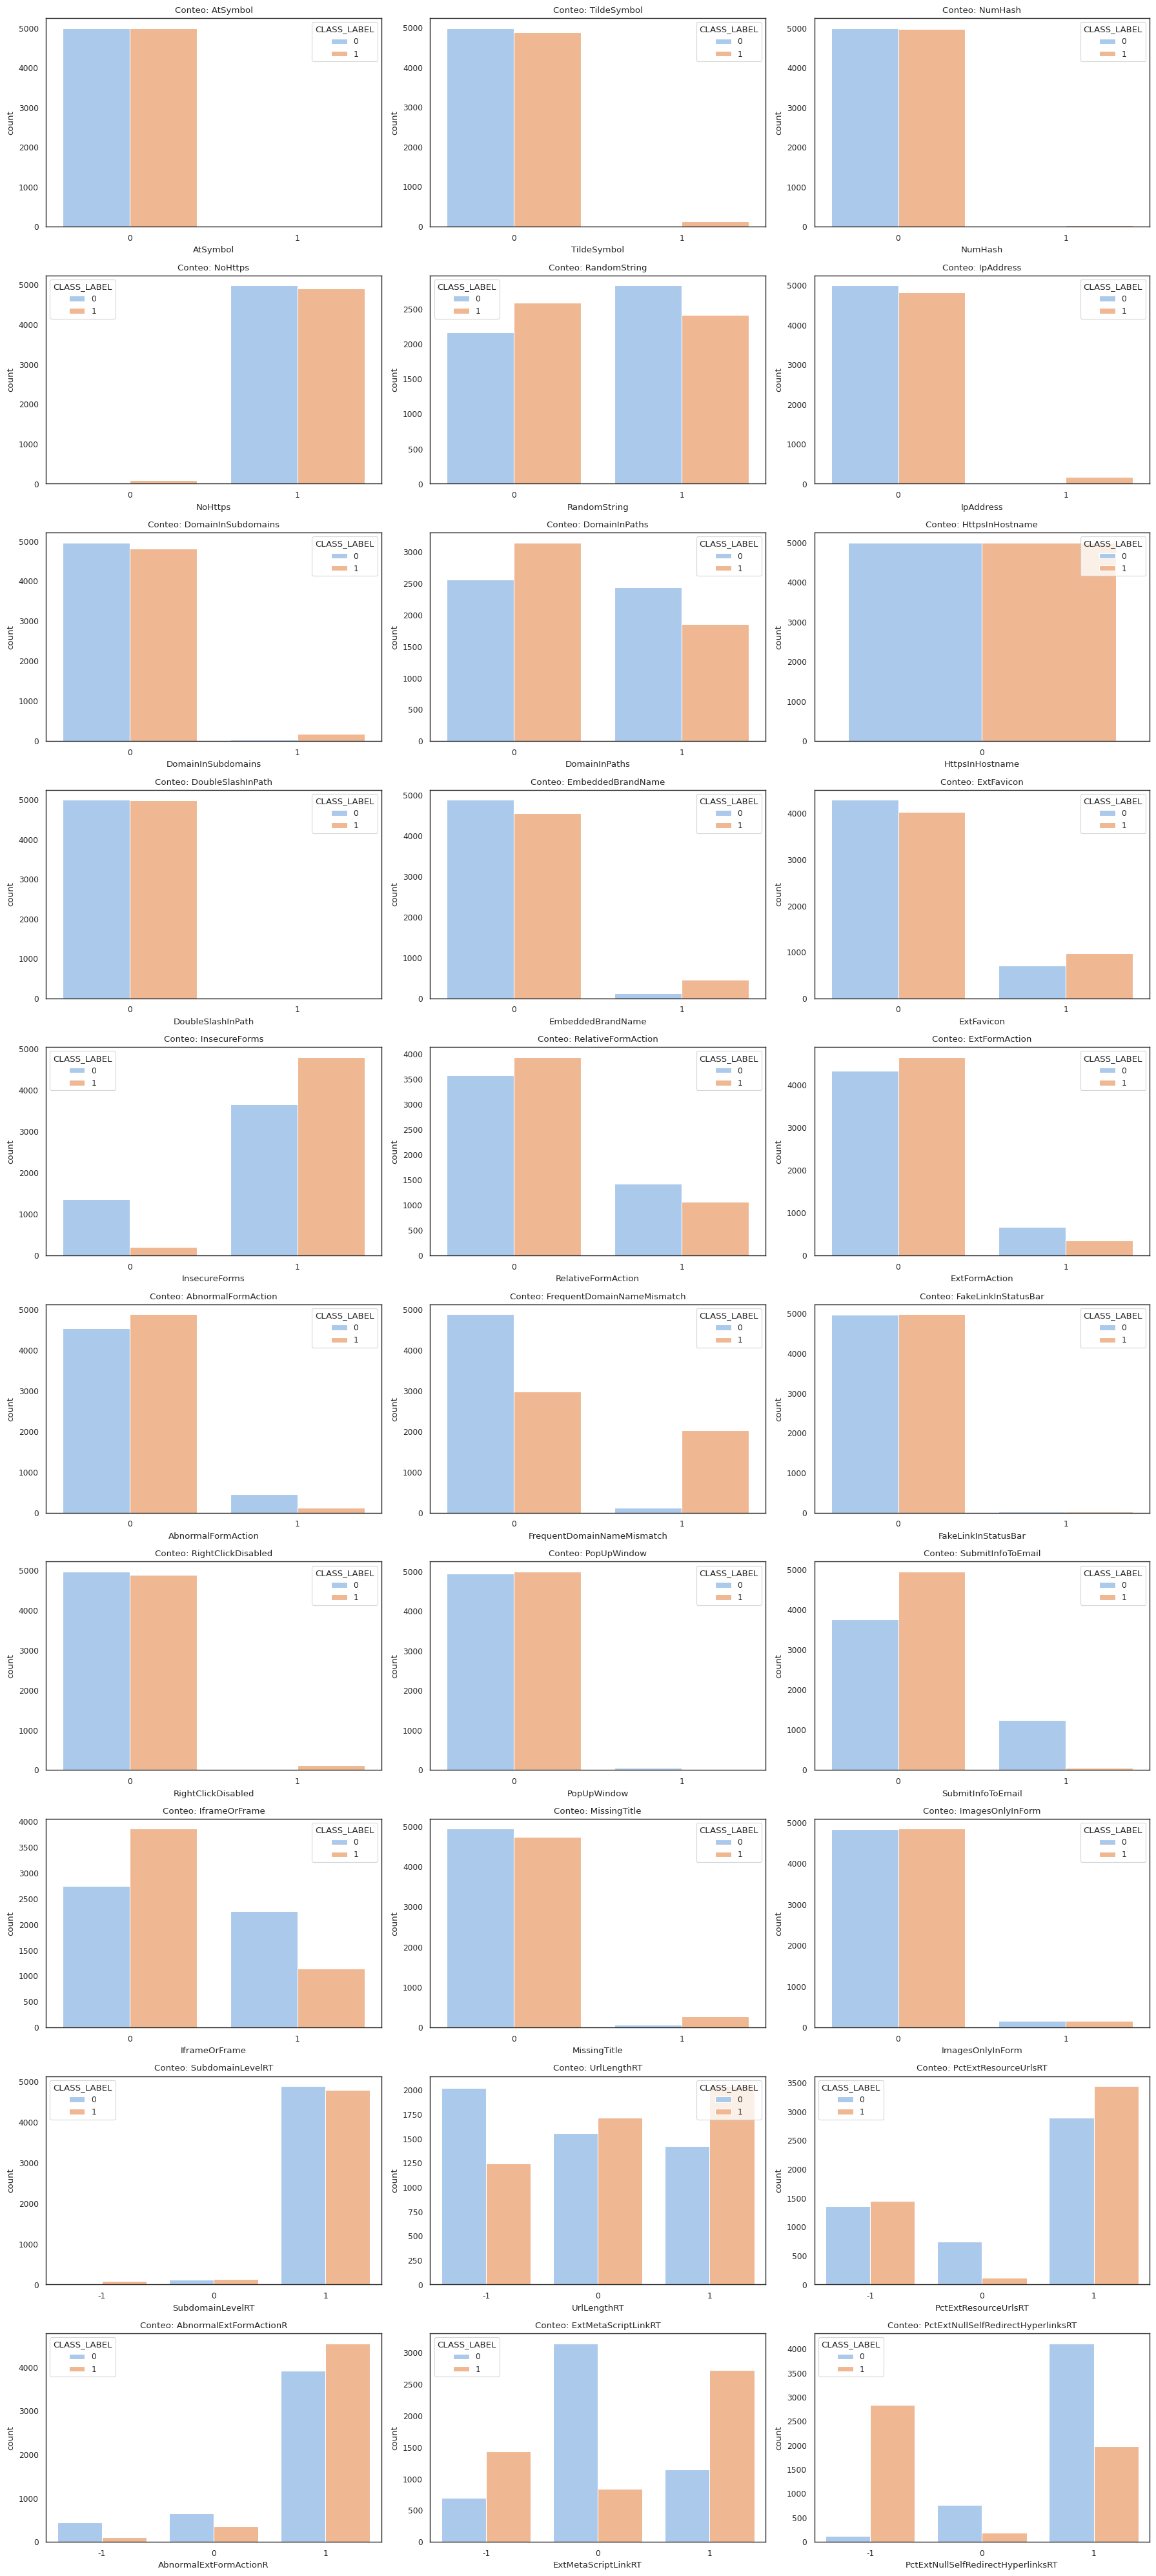

In [ ]:
# 2. Countplots para todas las binarias/categóricas
cat_cols = [c for c in phishing_data.columns if phishing_data[c].nunique() <= 3 and c != 'CLASS_LABEL']
n_cat = len(cat_cols)
if n_cat > 0:
    ncols = 3
    nrows = ceil(n_cat / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(cat_cols):
        try:
            sns.countplot(data=phishing_data, x=col, hue='CLASS_LABEL', ax=axes[i], palette="pastel")
            axes[i].set_title(f'Conteo: {col}')
        except Exception as e:
            axes[i].set_visible(False)
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()




📈 SCATTER PLOTS Y COUNTPLOTS DE CARACTERÍSTICAS


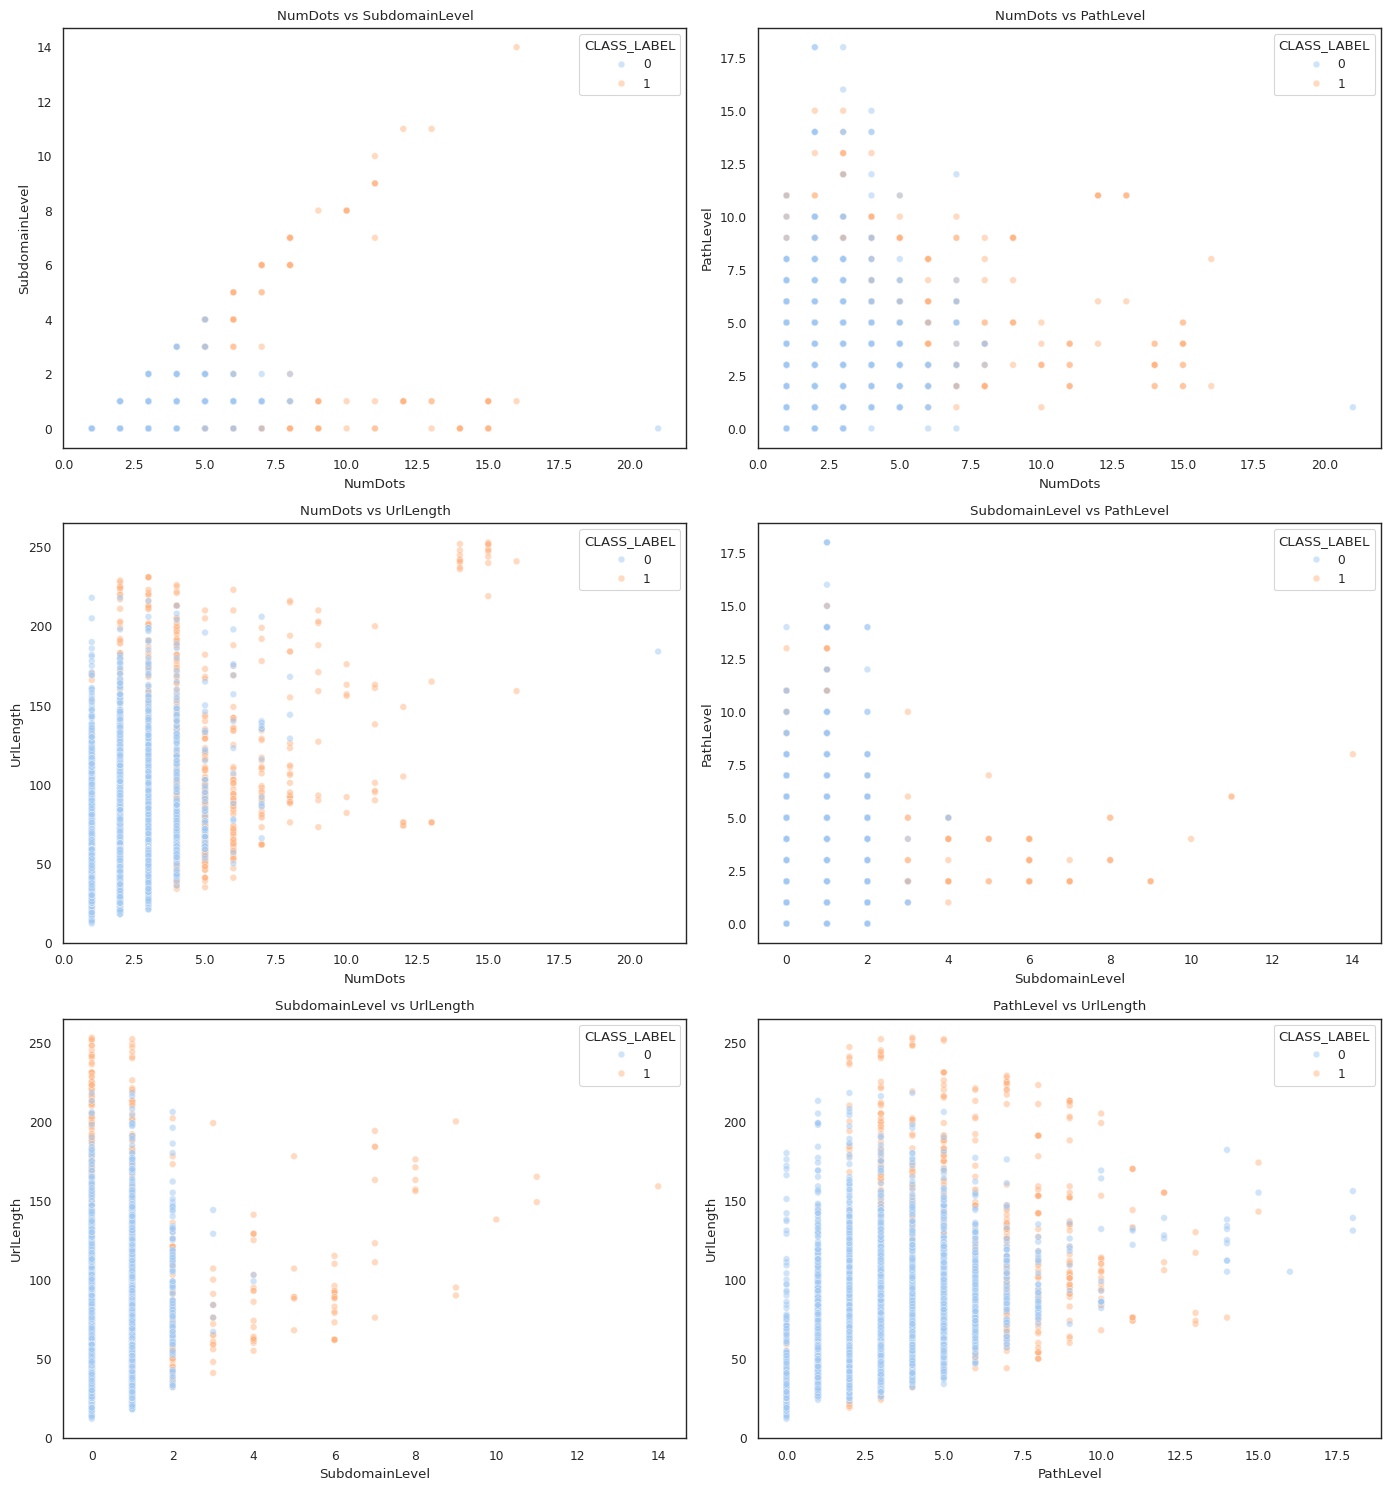

In [ ]:
#
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

print("\n\n📈 SCATTER PLOTS Y COUNTPLOTS DE CARACTERÍSTICAS")
print("=" * 55)

# SCATTER PLOTS para pares de variables numéricas
numeric_cols = phishing_data.select_dtypes(include=[np.number]).columns.tolist()
if 'CLASS_LABEL' in numeric_cols:
    numeric_cols.remove('CLASS_LABEL')

# Solo los primeros 3 pares para no saturar
scatter_pairs = list(itertools.combinations(numeric_cols[:4], 2))
n_scatter = len(scatter_pairs)

# Definir layout: 2 gráficos por fila
cols = 2
rows = (n_scatter + cols - 1) // cols  # redondeo hacia arriba
fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 5*rows))

# Asegurar que axes sea una matriz 2D
axes = np.array(axes).reshape(rows, cols)

# Graficar cada par
for idx, (x, y) in enumerate(scatter_pairs):
    r, c = divmod(idx, cols)
    ax = axes[r, c]
    sns.scatterplot(data=phishing_data, x=x, y=y, hue='CLASS_LABEL', alpha=0.5, palette='pastel', ax=ax)
    ax.set_title(f'{x} vs {y}')
    ax.legend(title='CLASS_LABEL')

# Ocultar ejes vacíos si sobran
for idx in range(n_scatter, rows * cols):
    r, c = divmod(idx, cols)
    fig.delaxes(axes[r, c])

plt.tight_layout()
plt.show()






🎯 2. SELECCIÓN DE CARACTERÍSTICAS CON LASSO
📊 Preparando datos para LASSO:
   - Características originales: 48
   - Muestras totales: 10,000
📊 División de datos:
  - Training: 8,000 muestras
  - Testing: 2,000 muestras
  - Características: 48

🔍 Ejecutando LASSO con validación cruzada...
✅ Mejor alpha encontrado: 0.000270
📊 Score de validación cruzada: 0.6872
🎯 Características seleccionadas por LASSO: 45/48
📉 Reducción de dimensionalidad: 6.2%

📋 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES:
    1. PctExtNullSelfRedirectHyperlinksRT | Coef:  -0.309 | ⬇️ disminuye riesgo
    2. PctExtHyperlinks               | Coef:  -0.183 | ⬇️ disminuye riesgo
    3. FrequentDomainNameMismatch     | Coef:   0.157 | ⬆️ aumenta riesgo
    4. NumQueryComponents             | Coef:  -0.109 | ⬇️ disminuye riesgo
    5. PctNullSelfRedirectHyperlinks  | Coef:  -0.109 | ⬇️ disminuye riesgo
    6. InsecureForms                  | Coef:   0.108 | ⬆️ aumenta riesgo
    7. NumDash                        | Coef:  -0.0

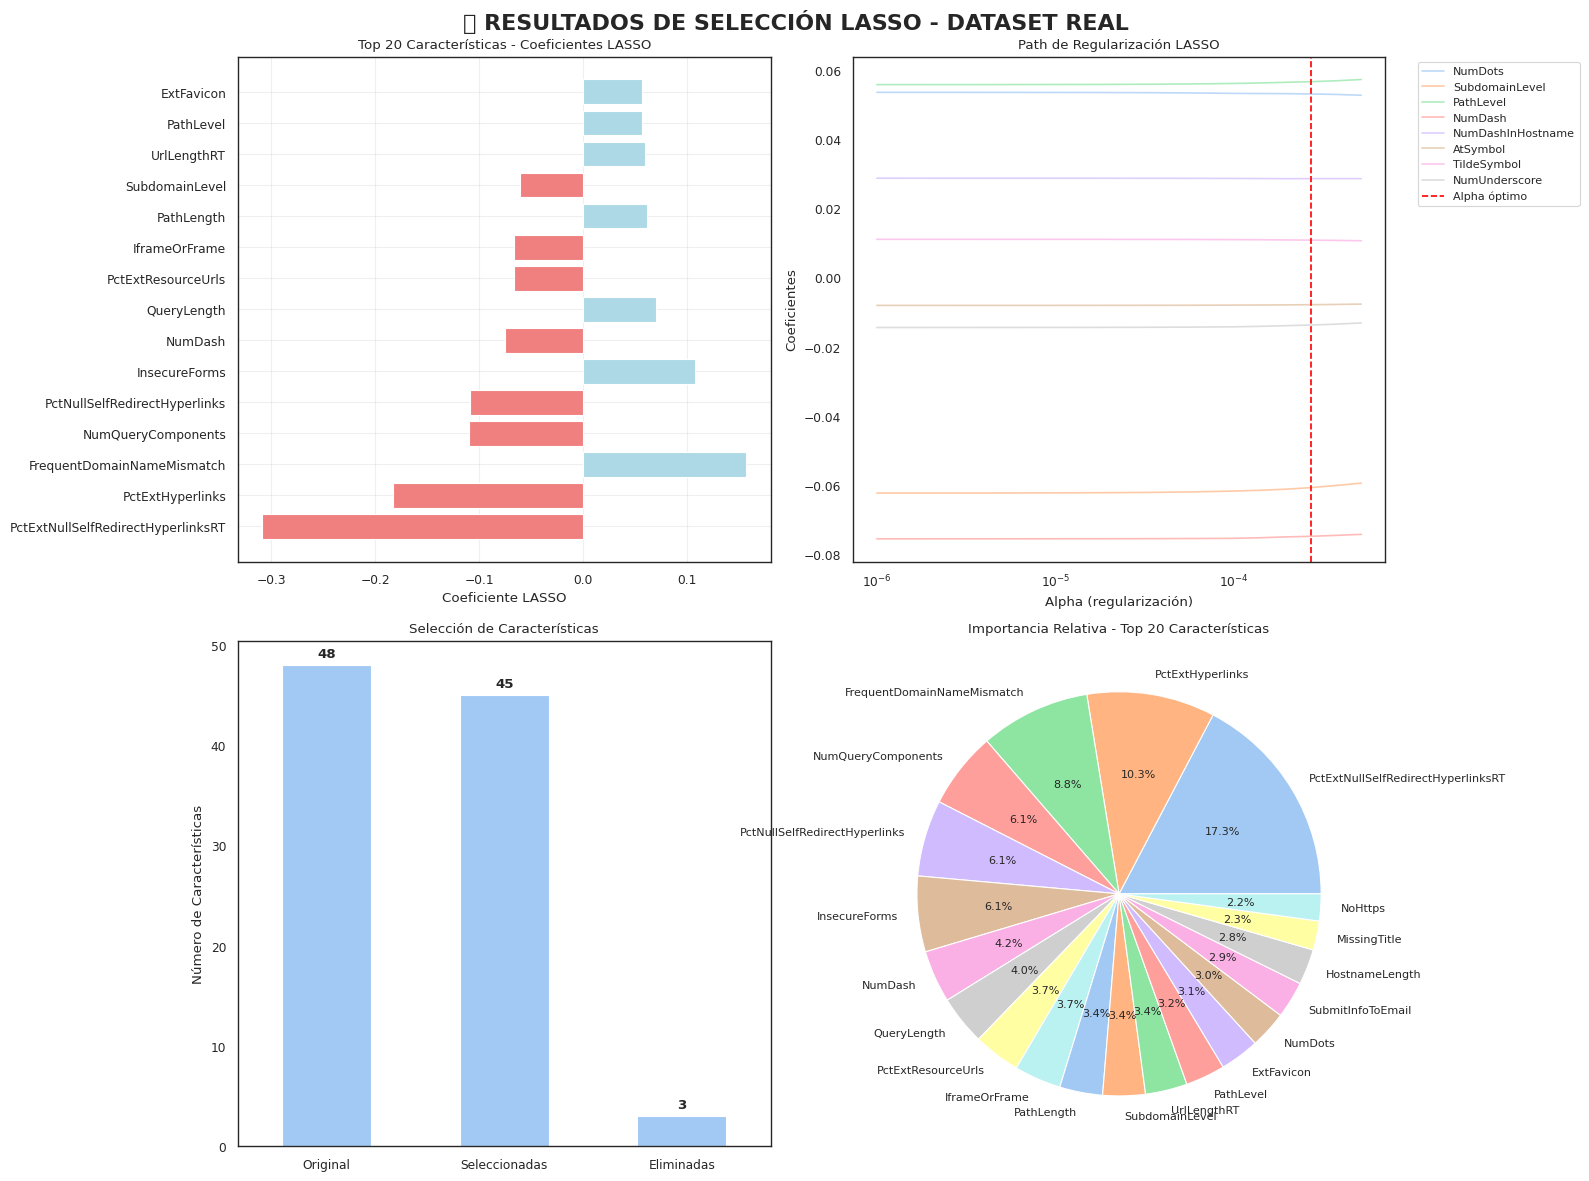

In [7]:
# =============================================================================
# 2. SELECCIÓN DE CARACTERÍSTICAS CON LASSO
# =============================================================================

print("\n\n🎯 2. SELECCIÓN DE CARACTERÍSTICAS CON LASSO")
print("=" * 50)

# Preparar datos para LASSO
X = phishing_data.drop(['CLASS_LABEL'], axis=1)
y = phishing_data['CLASS_LABEL']

print(f"📊 Preparando datos para LASSO:")
print(f"   - Características originales: {X.shape[1]}")
print(f"   - Muestras totales: {X.shape[0]:,}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print(f"📊 División de datos:")
print(f"  - Training: {X_train.shape[0]:,} muestras")
print(f"  - Testing: {X_test.shape[0]:,} muestras")
print(f"  - Características: {X_train.shape[1]}")

# LASSO con validación cruzada
print("\n🔍 Ejecutando LASSO con validación cruzada...")
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=3000)
lasso_cv.fit(X_train, y_train)

print(f"✅ Mejor alpha encontrado: {lasso_cv.alpha_:.6f}")
print(f"📊 Score de validación cruzada: {lasso_cv.score(X_train, y_train):.4f}")

# Seleccionar características con LASSO
selector = SelectFromModel(lasso_cv, prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Obtener características seleccionadas
selected_features = X.columns[selector.get_support()].tolist()
lasso_coefficients = lasso_cv.coef_[selector.get_support()]

print(f"🎯 Características seleccionadas por LASSO: {len(selected_features)}/{len(X.columns)}")
print(f"📉 Reducción de dimensionalidad: {(1 - len(selected_features)/len(X.columns))*100:.1f}%")

# Crear DataFrame con resultados LASSO
lasso_results = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': lasso_coefficients,
    'Abs_Coefficient': np.abs(lasso_coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print(f"\n📋 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES:")
for i, (idx, row) in enumerate(lasso_results.head(20).iterrows(), 1):
    direction = "⬆️ aumenta" if row['Coefficient'] > 0 else "⬇️ disminuye"
    print(f"   {i:2d}. {row['Feature']:30} | Coef: {row['Coefficient']:7.3f} | {direction} riesgo")

# Visualización de resultados LASSO
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🎯 RESULTADOS DE SELECCIÓN LASSO - DATASET REAL', fontsize=16, fontweight='bold')

# 1. Coeficientes LASSO
top_features = lasso_results.head(15)
colors = ['lightcoral' if coef < 0 else 'lightblue' for coef in top_features['Coefficient']]
axes[0, 0].barh(range(len(top_features)), top_features['Coefficient'], color=colors)
axes[0, 0].set_yticks(range(len(top_features)))
axes[0, 0].set_yticklabels(top_features['Feature'])
axes[0, 0].set_xlabel('Coeficiente LASSO')
axes[0, 0].set_title('Top 20 Características - Coeficientes LASSO')
axes[0, 0].grid(True, alpha=0.3)

# 2. Path de regularización (simplificado)
alphas = np.logspace(-6, 1, 50)
coefficients_path = []

print("🔄 Calculando path de regularización...")
for alpha in alphas[:20]:  # Limitamos para eficiencia
    lasso_temp = LassoCV(alphas=[alpha], cv=3, random_state=42, max_iter=1000)
    try:
        lasso_temp.fit(X_train, y_train)
        coefficients_path.append(lasso_temp.coef_)
    except:
        break

if coefficients_path:
    coefficients_path = np.array(coefficients_path)
    # Plotear path para top características seleccionadas
    top_indices = [X.columns.get_loc(feat) for feat in selected_features[:8]]

    for i, idx in enumerate(top_indices):
        if i < len(coefficients_path[0]):
            axes[0, 1].plot(alphas[:len(coefficients_path)],
                           coefficients_path[:, idx],
                           label=selected_features[i], alpha=0.7)

    axes[0, 1].axvline(lasso_cv.alpha_, color='red', linestyle='--', label='Alpha óptimo')
    axes[0, 1].set_xscale('log')
    axes[0, 1].set_xlabel('Alpha (regularización)')
    axes[0, 1].set_ylabel('Coeficientes')
    axes[0, 1].set_title('Path de Regularización LASSO')
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# 3. Comparación de características antes/después LASSO
feature_comparison = pd.DataFrame({
    'Cantidad': [len(X.columns), len(selected_features), len(X.columns) - len(selected_features)]
}, index=['Original', 'Seleccionadas', 'Eliminadas'])

feature_comparison.plot(kind='bar', ax=axes[1, 0],
                       color=sns.color_palette("pastel"))
axes[1, 0].set_title('Selección de Características')
axes[1, 0].set_ylabel('Número de Características')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend().remove()

# Añadir valores en las barras
for i, v in enumerate(feature_comparison['Cantidad']):
    axes[1, 0].text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

# 4. Importancia relativa
if len(lasso_results) > 0:
    normalized_importance = lasso_results['Abs_Coefficient'] / lasso_results['Abs_Coefficient'].sum()
    lasso_results['Relative_Importance'] = normalized_importance * 100

    top_20_importance = lasso_results.head(20)
    wedges, texts, autotexts = axes[1, 1].pie(top_20_importance['Relative_Importance'],
                                             labels=top_20_importance['Feature'],
                                             autopct='%1.1f%%',
                                             colors=sns.color_palette("pastel", len(top_20_importance)))

    # Mejorar legibilidad
    for autotext in autotexts:
        autotext.set_fontsize(8)
    for text in texts:
        text.set_fontsize(8)

    axes[1, 1].set_title('Importancia Relativa - Top 20 Características')

plt.tight_layout()
plt.show()




🔬 3. ANÁLISIS PROFUNDO - CARACTERÍSTICAS SELECCIONADAS


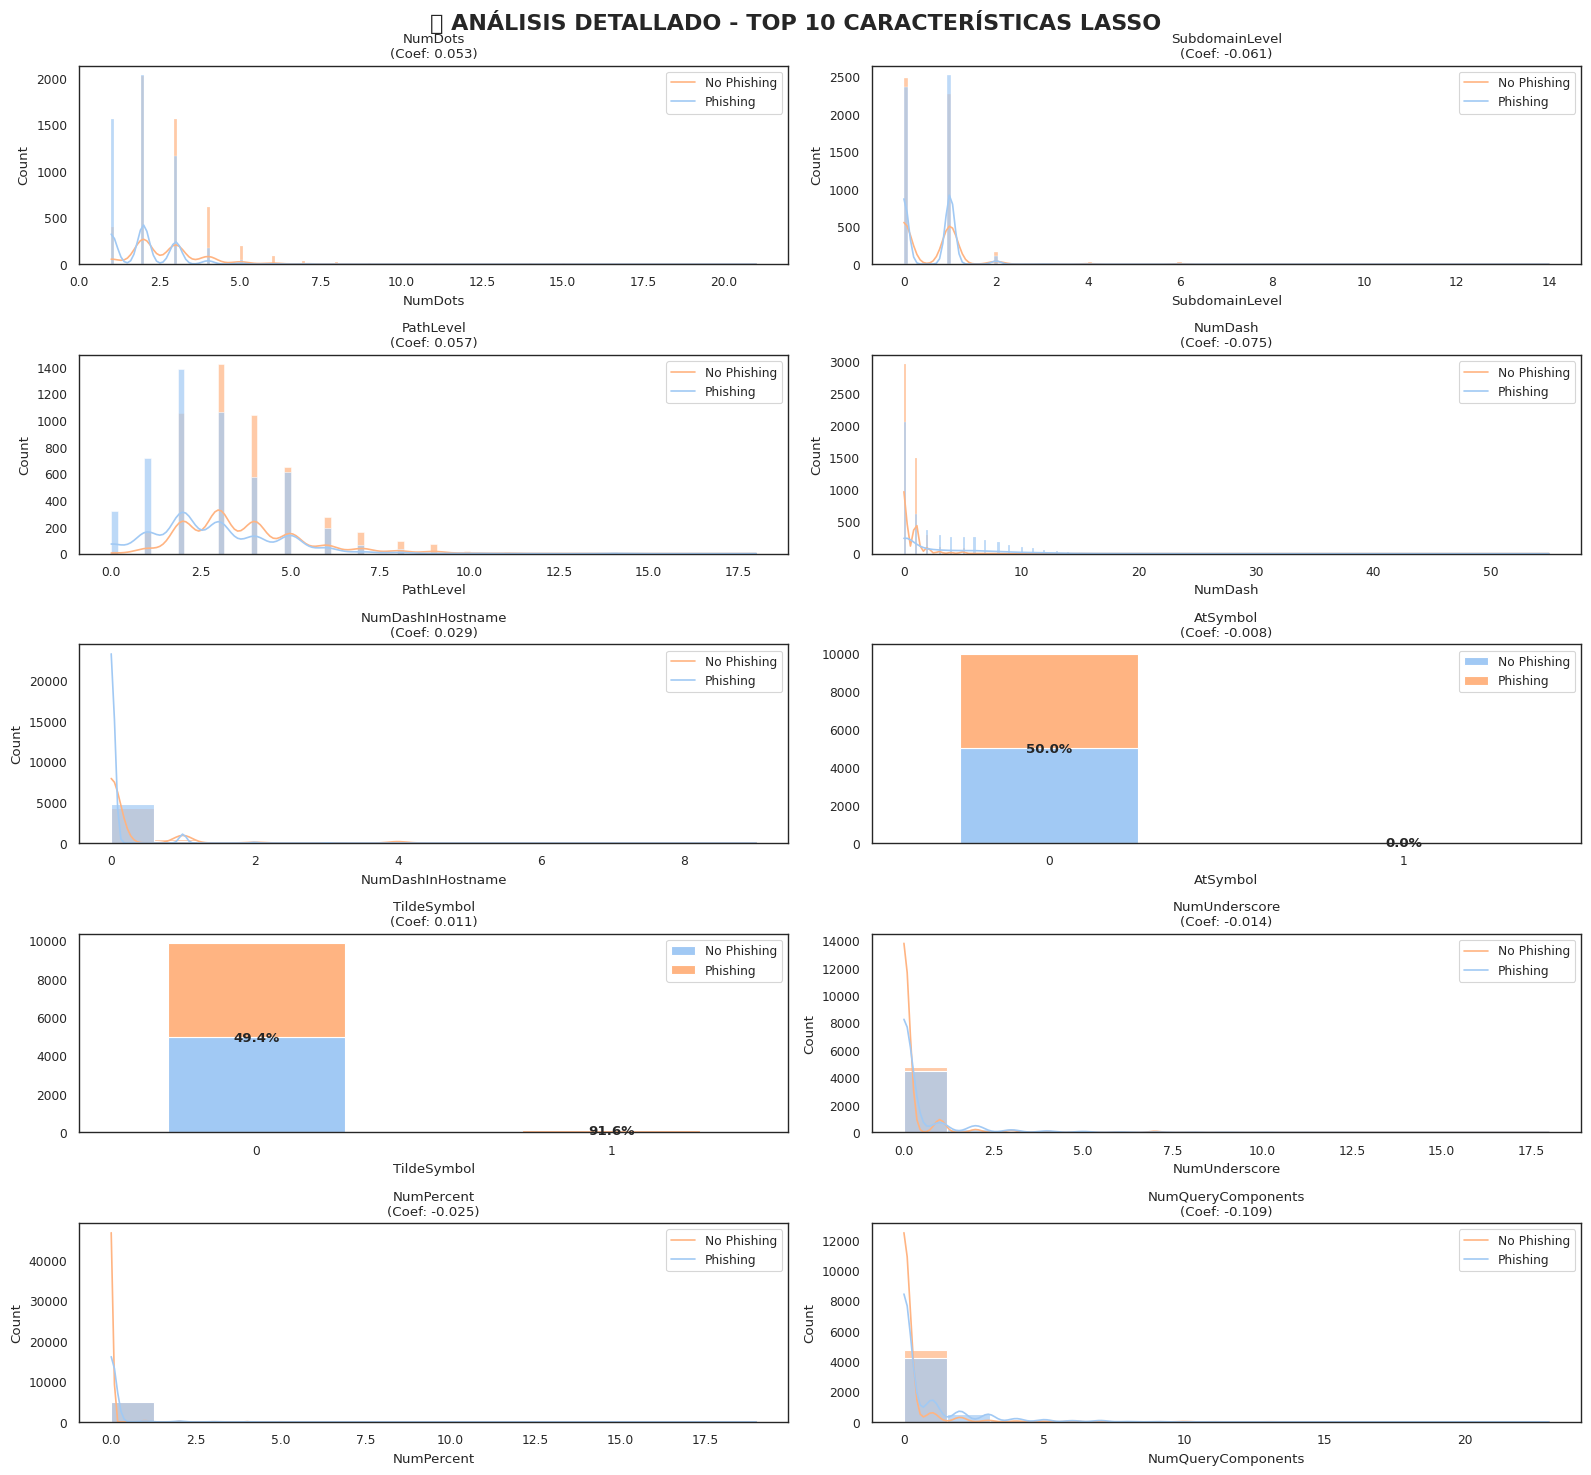

In [8]:
# =============================================================================
# 3. ANÁLISIS PROFUNDO DE CARACTERÍSTICAS SELECCIONADAS
# =============================================================================

print("\n\n🔬 3. ANÁLISIS PROFUNDO - CARACTERÍSTICAS SELECCIONADAS")
print("=" * 60)

if len(selected_features) > 0:
    # Análisis detallado de top características
    top_10_features = selected_features[:10]

    fig, axes = plt.subplots(5, 2, figsize=(16, 15))
    fig.suptitle('🔬 ANÁLISIS DETALLADO - TOP 10 CARACTERÍSTICAS LASSO',
                 fontsize=16, fontweight='bold')

    for i, feature in enumerate(top_10_features):
        row, col = i // 2, i % 2

        # Determinar si es binaria o continua
        unique_vals = phishing_data[feature].nunique()
        is_binary = unique_vals <= 3

        coef_value = lasso_results[lasso_results["Feature"]==feature]["Coefficient"].iloc[0]

        if is_binary:
            # Para características binarias/categóricas
            cross_tab = pd.crosstab(phishing_data[feature], phishing_data['CLASS_LABEL'])
            cross_tab_pct = pd.crosstab(phishing_data[feature], phishing_data['CLASS_LABEL'],
                                       normalize='index')

            # Gráfico de barras apiladas
            cross_tab.plot(kind='bar', stacked=True, ax=axes[row, col],
                          color=sns.color_palette("pastel"))
            axes[row, col].set_title(f'{feature}\n(Coef: {coef_value:.3f})')
            axes[row, col].tick_params(axis='x', rotation=0)
            axes[row, col].legend(['No Phishing', 'Phishing'])

            # Añadir porcentajes como texto
            for j, (idx, row_data) in enumerate(cross_tab.iterrows()):
                total = row_data.sum()
                if total > 0:
                    phishing_pct = row_data[1] / total * 100 if 1 in row_data.index else 0
                    axes[row, col].text(j, total/2, f'{phishing_pct:.1f}%',
                                       ha='center', va='center', fontweight='bold')
        else:
            # Para características continuas
            sns.histplot(data=phishing_data, x=feature, hue='CLASS_LABEL',
                        kde=True, alpha=0.7, ax=axes[row, col])
            axes[row, col].set_title(f'{feature}\n(Coef: {coef_value:.3f})')
            axes[row, col].legend(['No Phishing', 'Phishing'])

    plt.tight_layout()
    plt.show()





🎨 4. PAIR PLOT - CARACTERÍSTICAS SELECCIONADAS
📊 Generando pair plot con 5 características...


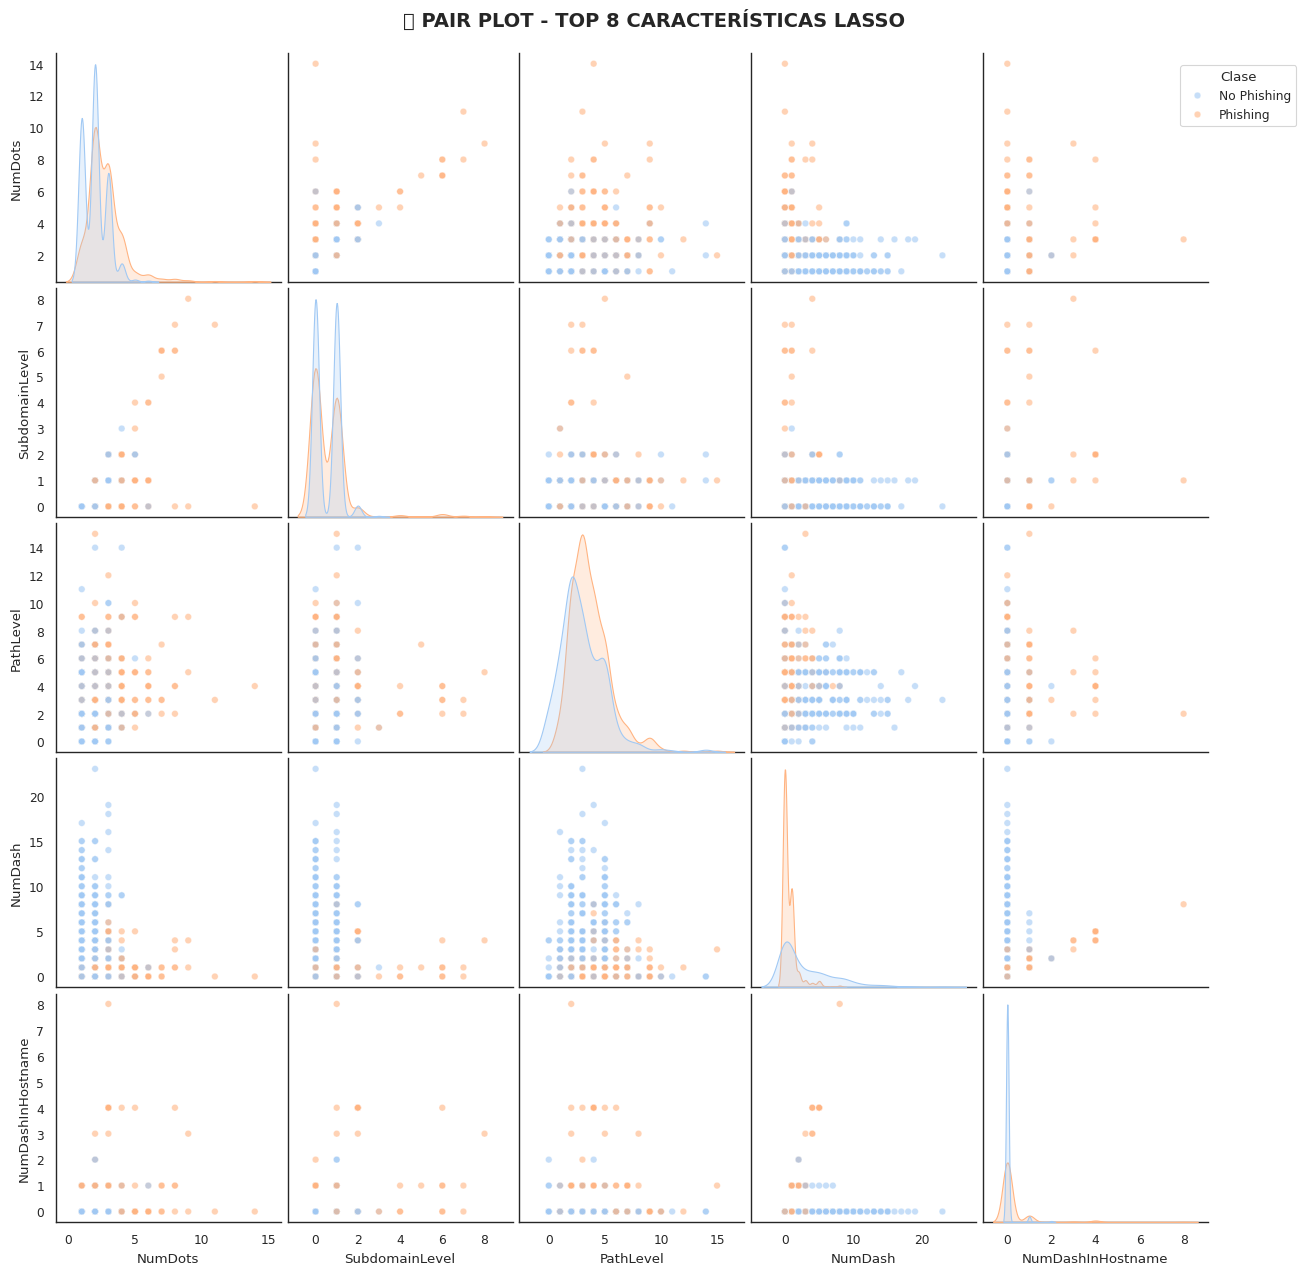

In [9]:
# =============================================================================
# 4. PAIR PLOT DE CARACTERÍSTICAS SELECCIONADAS
# =============================================================================

print("\n\n🎨 4. PAIR PLOT - CARACTERÍSTICAS SELECCIONADAS")
print("=" * 50)

if len(selected_features) >= 5:
    # Pair plot con top características
    pair_features = selected_features[:5] + ['CLASS_LABEL']
    sample_for_pair = phishing_data[pair_features].sample(min(1000, len(phishing_data)))

    print(f"📊 Generando pair plot con {len(pair_features)-1} características...")

    g = sns.pairplot(sample_for_pair, hue='CLASS_LABEL', diag_kind='kde',
                     palette="pastel", plot_kws={'alpha': 0.6})
    g.fig.suptitle('🎨 PAIR PLOT - TOP 8 CARACTERÍSTICAS LASSO', y=1.02, fontsize=14, fontweight='bold')

    # Personalizar leyenda
    handles = g._legend_data.values()
    labels = ['No Phishing', 'Phishing']
    g._legend.remove()
    g.fig.legend(handles, labels, title='Clase', loc='upper right', bbox_to_anchor=(0.98, 0.98))

    plt.show()




🌡️ 5. HEATMAPS AVANZADOS


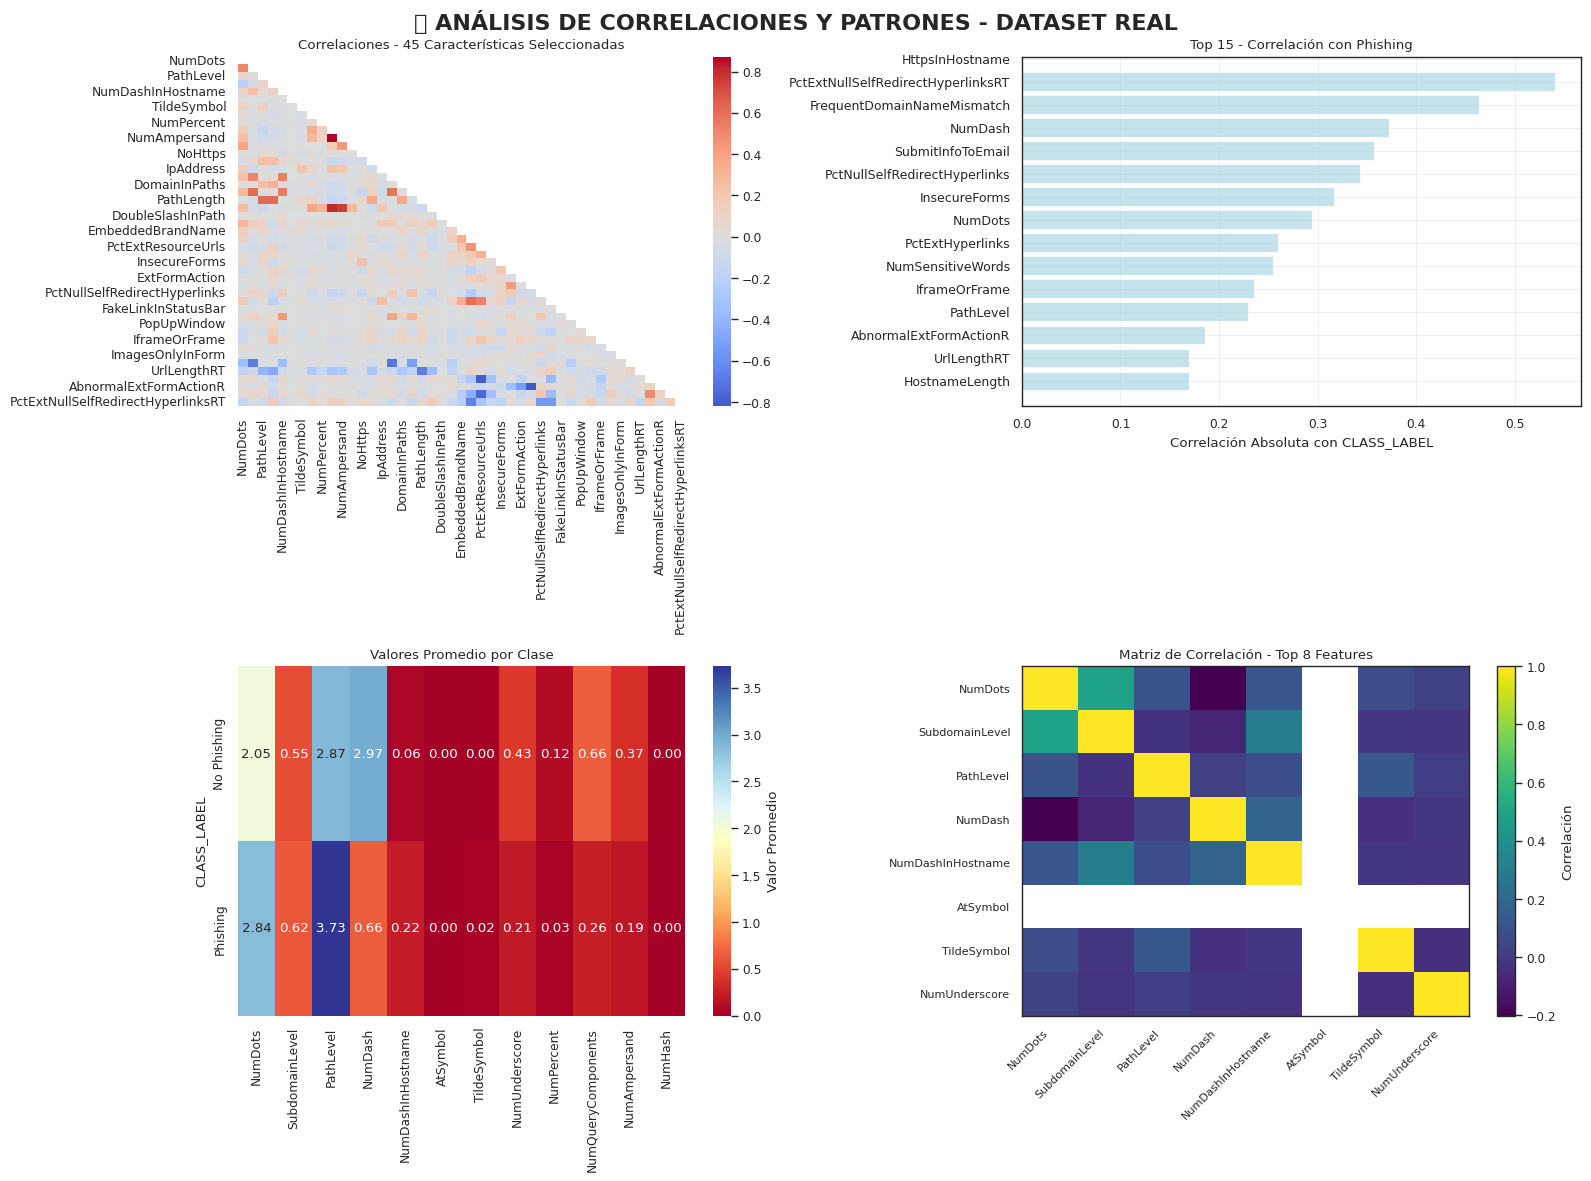

In [10]:
# =============================================================================
# 5. HEATMAPS AVANZADOS
# =============================================================================

print("\n\n🌡️ 5. HEATMAPS AVANZADOS")
print("=" * 40)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🌡️ ANÁLISIS DE CORRELACIONES Y PATRONES - DATASET REAL', fontsize=16, fontweight='bold')

# 1. Heatmap de características seleccionadas
if len(selected_features) > 1:
    selected_corr = phishing_data[selected_features].corr()
    mask = np.triu(np.ones_like(selected_corr, dtype=bool))
    sns.heatmap(selected_corr, mask=mask, annot=False, fmt='.2f',
                cmap='coolwarm', center=0, ax=axes[0, 0])
    axes[0, 0].set_title(f'Correlaciones - {len(selected_features)} Características Seleccionadas')

# 2. Correlación con target
all_features = feature_columns + ['CLASS_LABEL']
target_correlations = phishing_data[all_features].corr()['CLASS_LABEL'].drop('CLASS_LABEL')
target_correlations_sorted = target_correlations.abs().sort_values(ascending=True).tail(15)

colors = ['lightcoral' if x < 0 else 'lightblue' for x in target_correlations_sorted]
axes[0, 1].barh(range(len(target_correlations_sorted)), target_correlations_sorted.values,
                color=colors, alpha=0.7)
axes[0, 1].set_yticks(range(len(target_correlations_sorted)))
axes[0, 1].set_yticklabels(target_correlations_sorted.index, fontsize=9)
axes[0, 1].set_xlabel('Correlación Absoluta con CLASS_LABEL')
axes[0, 1].set_title('Top 15 - Correlación con Phishing')
axes[0, 1].grid(True, alpha=0.3)

# 3. Heatmap de medias por clase
if len(selected_features) > 0:
    features_for_heatmap = selected_features[:12] if len(selected_features) > 12 else selected_features
    means_by_class = phishing_data.groupby('CLASS_LABEL')[features_for_heatmap].mean()
    sns.heatmap(means_by_class, annot=True, fmt='.2f', cmap='RdYlBu',
                ax=axes[1, 0], cbar_kws={'label': 'Valor Promedio'})
    axes[1, 0].set_title('Valores Promedio por Clase')
    axes[1, 0].set_yticklabels(['No Phishing', 'Phishing'])

# 4. Clustermap de características similares
if len(selected_features) >= 8:
    sample_features = selected_features[:8]
    sample_data = phishing_data[sample_features].sample(min(500, len(phishing_data)))
    corr_matrix = sample_data.corr()

    # Crear heatmap en el subplot
    im = axes[1, 1].imshow(corr_matrix, cmap='viridis', aspect='auto')
    axes[1, 1].set_xticks(range(len(sample_features)))
    axes[1, 1].set_yticks(range(len(sample_features)))
    axes[1, 1].set_xticklabels(sample_features, rotation=45, ha='right', fontsize=8)
    axes[1, 1].set_yticklabels(sample_features, fontsize=8)
    axes[1, 1].set_title('Matriz de Correlación - Top 8 Features')

    # Añadir colorbar
    cbar = plt.colorbar(im, ax=axes[1, 1])
    cbar.set_label('Correlación')

plt.tight_layout()
plt.show()




📊 6. DASHBOARD FINAL - PERFORMANCE DEL MODELO
🤖 Entrenando modelos...
📊 MÉTRICAS DE PERFORMANCE:
   Modelo Completo    - Accuracy: 0.952, F1: 0.952
   Modelo LASSO       - Accuracy: 0.952, F1: 0.952


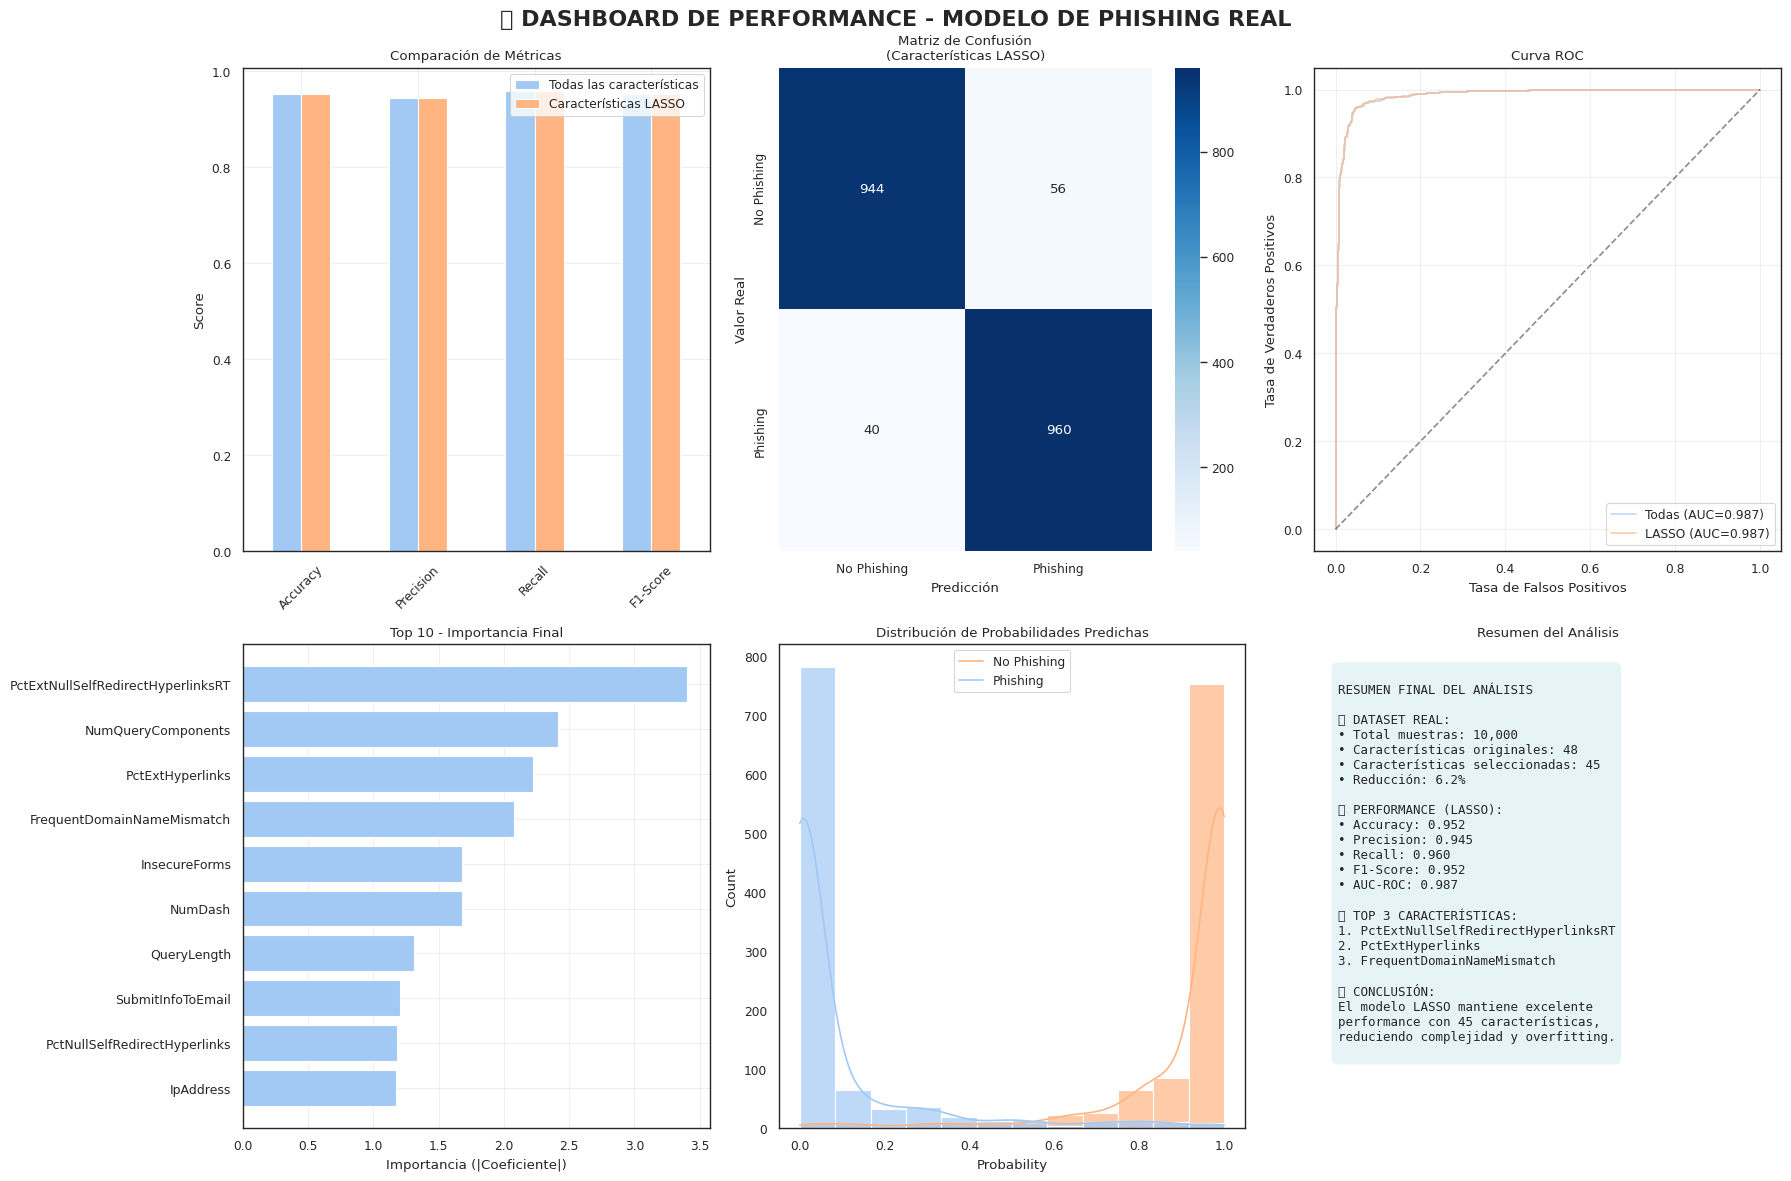

In [ ]:
# =============================================================================
# 6. DASHBOARD FINAL DE PERFORMANCE
# =============================================================================

print("\n\n📊 6. DASHBOARD FINAL - PERFORMANCE DEL MODELO")
print("=" * 55)

# Entrenar modelos para comparación
print("🤖 Entrenando modelos...")

# Modelo con todas las características
lr_full = LogisticRegression(random_state=42, max_iter=1000)
lr_full.fit(X_train, y_train)
y_pred_full = lr_full.predict(X_test)

# Modelo con características seleccionadas
lr_selected = LogisticRegression(random_state=42, max_iter=1000)
lr_selected.fit(X_train_selected, y_train)
y_pred_selected = lr_selected.predict(X_test_selected)

# Calcular métricas
def calculate_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

metrics_full = calculate_metrics(y_test, y_pred_full)
metrics_selected = calculate_metrics(y_test, y_pred_selected)

print("📊 MÉTRICAS DE PERFORMANCE:")
print(f"   Modelo Completo    - Accuracy: {metrics_full['Accuracy']:.3f}, F1: {metrics_full['F1-Score']:.3f}")
print(f"   Modelo LASSO       - Accuracy: {metrics_selected['Accuracy']:.3f}, F1: {metrics_selected['F1-Score']:.3f}")

# Dashboard de performance
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('📊 DASHBOARD DE PERFORMANCE - MODELO DE PHISHING REAL',
             fontsize=16, fontweight='bold')

# 1. Comparación de métricas
metrics_df = pd.DataFrame({
    'Todas las características': list(metrics_full.values()),
    'Características LASSO': list(metrics_selected.values())
}, index=list(metrics_full.keys()))

metrics_df.plot(kind='bar', ax=axes[0, 0], color=sns.color_palette("pastel"))
axes[0, 0].set_title('Comparación de Métricas')
axes[0, 0].set_ylabel('Score')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Matriz de confusión - modelo seleccionado
cm = confusion_matrix(y_test, y_pred_selected)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['No Phishing', 'Phishing'],
            yticklabels=['No Phishing', 'Phishing'])
axes[0, 1].set_title('Matriz de Confusión\n(Características LASSO)')
axes[0, 1].set_ylabel('Valor Real')
axes[0, 1].set_xlabel('Predicción')

# 3. ROC Curve
y_prob_full = lr_full.predict_proba(X_test)[:, 1]
y_prob_selected = lr_selected.predict_proba(X_test_selected)[:, 1]

fpr_full, tpr_full, _ = roc_curve(y_test, y_prob_full)
fpr_selected, tpr_selected, _ = roc_curve(y_test, y_prob_selected)

auc_full = roc_auc_score(y_test, y_prob_full)
auc_selected = roc_auc_score(y_test, y_prob_selected)

axes[0, 2].plot(fpr_full, tpr_full, label=f'Todas (AUC={auc_full:.3f})', alpha=0.7)
axes[0, 2].plot(fpr_selected, tpr_selected, label=f'LASSO (AUC={auc_selected:.3f})', alpha=0.7)
axes[0, 2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0, 2].set_xlabel('Tasa de Falsos Positivos')
axes[0, 2].set_ylabel('Tasa de Verdaderos Positivos')
axes[0, 2].set_title('Curva ROC')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Feature importance final
if len(selected_features) > 0:
    feature_importance_final = pd.DataFrame({
        'Feature': selected_features,
        'Importance': np.abs(lr_selected.coef_[0])
    }).sort_values('Importance', ascending=True).tail(10)

    axes[1, 0].barh(range(len(feature_importance_final)),
                    feature_importance_final['Importance'],
                    color=sns.color_palette("pastel")[0])
    axes[1, 0].set_yticks(range(len(feature_importance_final)))
    axes[1, 0].set_yticklabels(feature_importance_final['Feature'], fontsize=9)
    axes[1, 0].set_xlabel('Importancia (|Coeficiente|)')
    axes[1, 0].set_title('Top 10 - Importancia Final')
    axes[1, 0].grid(True, alpha=0.3)

# 5. Distribución de probabilidades
prob_df = pd.DataFrame({
    'Probability': y_prob_selected,
    'True_Label': y_test
})

sns.histplot(data=prob_df, x='Probability', hue='True_Label',
             kde=True, alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Distribución de Probabilidades Predichas')
axes[1, 1].legend(['No Phishing', 'Phishing'])


# 6. Resumen numérico
summary_text = f"""
RESUMEN FINAL DEL ANÁLISIS

📊 DATASET REAL:
• Total muestras: {len(phishing_data):,}
• Características originales: {len(X.columns)}
• Características seleccionadas: {len(selected_features)}
• Reducción: {(1 - len(selected_features)/len(X.columns))*100:.1f}%

🎯 PERFORMANCE (LASSO):
• Accuracy: {metrics_selected['Accuracy']:.3f}
• Precision: {metrics_selected['Precision']:.3f}
• Recall: {metrics_selected['Recall']:.3f}
• F1-Score: {metrics_selected['F1-Score']:.3f}
• AUC-ROC: {auc_selected:.3f}

🏆 TOP 3 CARACTERÍSTICAS:
"""

if len(lasso_results) >= 3:
    for i in range(3):
        summary_text += f"{i+1}. {lasso_results.iloc[i]['Feature']}\n"

summary_text += f"""
✅ CONCLUSIÓN:
El modelo LASSO mantiene excelente
performance con {len(selected_features)} características,
reduciendo complejidad y overfitting.
"""

axes[1, 2].text(0.05, 0.95, summary_text, transform=axes[1, 2].transAxes,
                fontsize=9, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.3))
axes[1, 2].axis('off')
axes[1, 2].set_title('Resumen del Análisis')

plt.tight_layout()
plt.show()

